# Innotram Data Exploration

Loading and inspecting the recorded Innotram sensor data.

In [1]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()

,t_v_plc,v_plc,t_v_gnss,v_gnss,t_latlon,lon,lat
0,-0.107469,0.00000,-0.072306,0.007200,0.378798,8.681309,49.862053
1,-0.014114,0.00000,0.024425,0.025960,1.378798,8.681309,49.862053
2,0.081911,0.00000,0.115079,0.014843,2.378798,8.681309,49.862053
3,0.192523,0.00000,0.247924,0.008050,3.378798,8.681309,49.862053
4,0.286721,0.02442,0.327148,0.012980,4.378798,8.681312,49.862053


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11090 entries, 0 to 11089
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   t_v_plc   11090 non-null  float64
 1   v_plc     11090 non-null  float64
 2   t_v_gnss  11076 non-null  float64
 3   v_gnss    11076 non-null  float64
 4   t_latlon  1108 non-null   float64
 5   lon       1108 non-null   float64
 6   lat       1108 non-null   float64
dtypes: float64(7)
memory usage: 606.6 KB


,t_v_plc,v_plc,t_v_gnss,v_gnss,t_latlon,lon,lat
count,11090.000000,11090.000000,11076.000000,11076.000000,1108.000000,1108.000000,1108.000000
mean,554.374044,15.847772,554.430693,15.809617,554.591343,8.656444,49.868537
std,320.176644,12.835422,320.389846,12.778566,320.592608,0.013514,0.004373
min,-0.107469,0.000000,-0.072306,0.000000,0.378798,8.631630,49.861268
25%,277.134675,3.369960,276.762801,3.389246,277.128798,8.646158,49.863590
50%,554.380503,15.457880,553.776997,15.389301,553.978798,8.656677,49.870511
75%,831.613205,23.858360,832.052246,23.800317,832.028798,8.666634,49.872184
max,1108.860138,52.356531,1108.912941,51.751347,1108.778798,8.681856,49.873155


In [3]:
# Check sampling rates and how many rows have GPS fixes
print("t_v_plc step  :", df["t_v_plc"].diff().median())
print("t_v_gnss step :", df["t_v_gnss"].diff().median())
print("t_latlon step :", df["t_latlon"].dropna().diff().median())
print("non-null lat/lon rows:", df["lat"].notna().sum(), "/", len(df))

t_v_plc step  : 0.0963587760925293
t_v_gnss step : 0.09999823570248623
t_latlon step : 1.0
non-null lat/lon rows: 1108 / 11090


## Column meanings

| Column | Likely meaning |
|---|---|
| `t_v_plc` | Timestamp (seconds, relative to recording start) for the **PLC speed** measurement. Sampled at ~10 Hz (0.1 s steps). |
| `v_plc` | Speed reported by the tram's **PLC** (Programmable Logic Controller — the vehicle's own control/drive system, e.g. derived from wheel/axle tachometers). Range ≈ 0–52, no missing values → this is the "ground truth" drive-train speed. |
| `t_v_gnss` | Timestamp for the **GNSS-derived speed** measurement, also ~10 Hz, with a few (14) gaps — consistent with occasional lost satellite fixes. |
| `v_gnss` | Speed derived from the **GNSS/GPS receiver** (e.g. Doppler shift or position differentiation). Very similar range to `v_plc`, so it's an independent cross-check of vehicle speed used to validate/fuse with the PLC value (important for an AI self-driving system that needs redundant, sensor-fused speed estimates). |
| `t_latlon` | Timestamp for the **position fix**, sampled ~10x slower (~1 Hz) than the speed signals — typical for GNSS position updates. |
| `lon`, `lat` | **Longitude / latitude** of the tram, only populated once every ~10 rows (matching the 1 Hz GPS update rate) — the rest are `NaN` because no new fix was available at that PLC/GNSS sample tick. Coordinates cluster around lat ≈ 49.86–49.87, lon ≈ 8.63–8.68, i.e. the Darmstadt area. |

A synchronized log of the tram's **speed from two independent sources (drive-train PLC vs. GNSS)** plus its **GPS position**, each on its own clock/timestamp column.

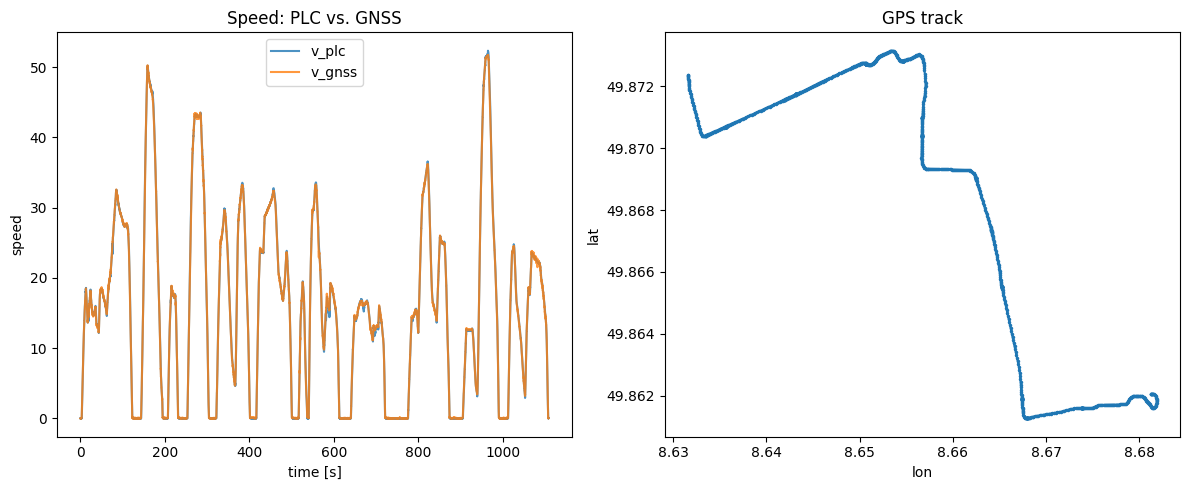

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Speed: PLC vs GNSS over time
axes[0].plot(df["t_v_plc"], df["v_plc"], label="v_plc", alpha=0.8)
axes[0].plot(df["t_v_gnss"], df["v_gnss"], label="v_gnss", alpha=0.8)
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("speed")
axes[0].set_title("Speed: PLC vs. GNSS")
axes[0].legend()

# GPS track
axes[1].plot(df["lon"], df["lat"], marker=".", linestyle="-", markersize=3)
axes[1].set_xlabel("lon")
axes[1].set_ylabel("lat")
axes[1].set_title("GPS track")

plt.tight_layout()
plt.show()

## Overlaying the route on a real map

`folium` renders an interactive Leaflet map.

In [9]:
import folium

track = df[["lat", "lon"]].dropna()

m = folium.Map(location=[track["lat"].mean(), track["lon"].mean()], zoom_start=15, tiles="OpenStreetMap")

folium.PolyLine(track[["lat", "lon"]].values, color="red", weight=4, opacity=0.8).add_to(m)
folium.Marker(track.iloc[0][["lat", "lon"]].tolist(), tooltip="Start", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(track.iloc[-1][["lat", "lon"]].tolist(), tooltip="End", icon=folium.Icon(color="red")).add_to(m)

m

In [11]:
import numpy as np

# Detect stop events: v_plc near zero (not exactly zero -- sensor noise
# jitters by one quantization step, ~0.024, even while the tram is fully
# stationary, which would fragment a single real stop into many if we
# required an exact ==0 match)
is_stopped = df["v_plc"] <= 0.05
stop_id = (is_stopped != is_stopped.shift(fill_value=False)).cumsum()

stops = (
    df[is_stopped]
    .groupby(stop_id[is_stopped])
    .agg(t_start=("t_v_plc", "first"), t_end=("t_v_plc", "last"), n=("t_v_plc", "size"))
    .reset_index(drop=True)
)

# Merge stop segments that are only briefly interrupted (<2s of motion)
# into a single stop -- this is residual noise, not the tram actually
# leaving and returning to the same station within a couple of seconds
merge_gap = 2.0
new_group = (stops["t_start"] - stops["t_end"].shift()) > merge_gap
stops["merged_id"] = new_group.cumsum()
stops = stops.groupby("merged_id").agg(t_start=("t_start", "first"), t_end=("t_end", "last"))

stops["duration"] = stops["t_end"] - stops["t_start"]
stops["t_mid"] = (stops["t_start"] + stops["t_end"]) / 2

# Keep only stops lasting at least 0.5s (filters out single-sample noise blips)
stops = stops[stops["duration"] >= 0.5].reset_index(drop=True)

# lat/lon are only sampled at ~1 Hz, so interpolate them onto each stop's mid-time
gps = df[["t_latlon", "lat", "lon"]].dropna().sort_values("t_latlon")
stops["lat"] = np.interp(stops["t_mid"], gps["t_latlon"], gps["lat"])
stops["lon"] = np.interp(stops["t_mid"], gps["t_latlon"], gps["lon"])

print(f"Detected {len(stops)} stop(s)")
stops[["t_start", "t_end", "duration", "lat", "lon"]]

Detected 13 stop(s)


,t_start,t_end,duration,lat,lon
0,-0.107469,3.392766,3.500235,49.862053,8.681309
1,124.091844,143.991516,19.899672,49.861593,8.673883
2,195.498796,207.392398,11.893602,49.861271,8.667948
3,231.701330,253.609556,21.908226,49.861881,8.667408
4,305.412232,322.214175,16.801943,49.865513,8.665251
5,401.819494,416.919715,15.100221,49.869023,8.662463
6,501.621136,517.126374,15.505238,49.870411,8.656677
7,537.214540,540.817986,3.603446,49.870986,8.656739
8,613.424645,640.833796,27.409151,49.872823,8.654626
9,722.441078,776.138743,53.697665,49.872740,8.650692


In [12]:
for _, row in stops.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        tooltip=f"Stop @ t={row['t_mid']:.1f}s (duration {row['duration']:.1f}s)",
        icon=folium.Icon(color="blue", icon="stop", prefix="fa"),
    ).add_to(m)

m

In [16]:
import branca.colormap as cm

# Interpolate v_plc onto each GPS fix's timestamp so every track point has a speed
track_v = df[["t_latlon", "lat", "lon"]].dropna().sort_values("t_latlon").reset_index(drop=True)
track_v["v_plc"] = np.interp(track_v["t_latlon"], df["t_v_plc"], df["v_plc"])

colormap = cm.LinearColormap(colors=["red", "green"], vmin=0, vmax=track_v["v_plc"].max())

m_speed = folium.Map(location=[track_v["lat"].mean(), track_v["lon"].mean()], zoom_start=15, tiles="OpenStreetMap")

# Draw the track as short segments, each colored by the speed at its starting point
for i in range(len(track_v) - 1):
    folium.PolyLine(
        locations=track_v.loc[i:i + 1, ["lat", "lon"]].values,
        color=colormap(track_v.loc[i, "v_plc"]),
        weight=10,
        opacity=0.9,
    ).add_to(m_speed)

for _, row in stops.iterrows():
    folium.Marker(
        [row["lat"], row["lon"]],
        tooltip=f"Stop @ t={row['t_mid']:.1f}s (duration {row['duration']:.1f}s)",
        icon=folium.Icon(color="blue", icon="stop", prefix="fa"),
    ).add_to(m_speed)


colormap.caption = "Speed v_plc (red = 0, green = max)"
colormap.add_to(m_speed)

m_speed